# COMP9444 26T2 — Project 005: Intelligent Food Image Recognition
## DenseNet-121 Semantic Segmentation Baseline

**Dataset:** UECFoodPixComplete  
**Experiment:** 3000 train / 500 validation / 30 epochs / seed 9444  
**Member:** Taixingjian  

---

## 1. Setup & Imports

In [1]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

print('PyTorch:', torch.__version__)
print('Device:', 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))


---
## 2. Experimental Configuration

Both baselines use the same proportional split and hyperparameters to ensure a fair comparison.

In [2]:
# ====== EXPERIMENT CONFIGURATION ======
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "dataset"  # Change this if the dataset is stored elsewhere

TRAIN_SIZE = 3000
VAL_SIZE = 500
SEED = 9444
EPOCHS = 30
IMAGE_SIZE = 128
BATCH_SIZE = 8
NUM_CLASSES = 103

print("Dataset root:", DATA_ROOT)
print(f"Train={TRAIN_SIZE}, Validation={VAL_SIZE}, Epochs={EPOCHS}, Seed={SEED}")


---
## 3. Proportional Train / Validation Split

Each image is assigned to its dominant foreground class. First, 3000 training images are sampled proportionally with seed 9444. The 500 validation images are then sampled from the remaining 6000 images with seed 9445. Therefore, the two subsets cannot overlap.

In [3]:
"""Create one deterministic proportional split shared by all baselines."""
from collections import defaultdict
from pathlib import Path
import csv
import random

import numpy as np
from PIL import Image


def _dominant_class(mask_path: Path) -> int:
    mask = np.asarray(Image.open(mask_path).getchannel("R"), dtype=np.uint8)
    counts = np.bincount(mask.ravel(), minlength=103)
    counts[0] = 0  # Stratify by food, not by the background area.
    return int(counts.argmax()) if counts.sum() else 0


def _proportional_sample(ids, labels, size, seed):
    groups = defaultdict(list)
    for sample_id in ids:
        groups[labels[sample_id]].append(sample_id)
    total = len(ids)
    raw = {label: size * len(group) / total for label, group in groups.items()}
    quota = {label: int(value) for label, value in raw.items()}
    remaining = size - sum(quota.values())
    order = sorted(groups, key=lambda label: (raw[label] - quota[label], len(groups[label]), -label), reverse=True)
    for label in order[:remaining]:
        quota[label] += 1

    rng = random.Random(seed)
    selected = []
    for label in sorted(groups):
        group = sorted(groups[label])
        rng.shuffle(group)
        selected.extend(group[:quota[label]])
    rng.shuffle(selected)
    assert len(selected) == size
    return selected


def get_or_create_split(data_root, train_size=3000, val_size=500, seed=9444):
    data_root = Path(data_root)
    split_dir = data_root / "splits" / f"train{train_size}_val{val_size}_seed{seed}"
    train_file, val_file = split_dir / "train_ids.txt", split_dir / "val_ids.txt"
    if train_file.exists() and val_file.exists():
        train_ids = train_file.read_text().splitlines()
        val_ids = val_file.read_text().splitlines()
    else:
        split_dir.mkdir(parents=True, exist_ok=True)
        all_ids = [x.strip() for x in (data_root / "train9000.txt").read_text().splitlines() if x.strip()]
        if train_size + val_size > len(all_ids):
            raise ValueError("train_size + val_size exceeds the available training images")
        print("Scanning masks to create the proportional split (only needed once)...")
        labels = {
            sample_id: _dominant_class(data_root / "UECFoodPIX" / "train" / "mask" / f"{sample_id}.png")
            for sample_id in all_ids
        }
        train_ids = _proportional_sample(all_ids, labels, train_size, seed)
        train_set = set(train_ids)
        remaining_ids = [sample_id for sample_id in all_ids if sample_id not in train_set]
        val_ids = _proportional_sample(remaining_ids, labels, val_size, seed + 1)
        train_file.write_text("\n".join(train_ids) + "\n")
        val_file.write_text("\n".join(val_ids) + "\n")
        with (split_dir / "class_distribution.csv").open("w", newline="") as f:
            writer = csv.writer(f); writer.writerow(["dominant_class", "train_count", "val_count"])
            for label in range(103):
                writer.writerow([label, sum(labels[x] == label for x in train_ids),
                                 sum(labels[x] == label for x in val_ids)])

    if len(train_ids) != train_size or len(val_ids) != val_size:
        raise ValueError("Saved split has an unexpected size")
    if set(train_ids) & set(val_ids):
        raise ValueError("Training and validation splits overlap")
    print(f"Shared proportional split: train={len(train_ids)}, validation={len(val_ids)}, seed={seed}")
    return train_ids, val_ids



In [4]:
# ====== CREATE / LOAD THE SHARED PROPORTIONAL SPLIT ======
train_ids, val_ids = get_or_create_split(
    DATA_ROOT,
    train_size=TRAIN_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
)

print("Training images:", len(train_ids))
print("Validation images:", len(val_ids))
print("Train/validation overlap:", len(set(train_ids) & set(val_ids)))

assert len(train_ids) == 3000
assert len(val_ids) == 500
assert len(set(train_ids) & set(val_ids)) == 0


Shared proportional split: train=3000, validation=500, seed=9444
Training images: 3000
Validation images: 500
Train/validation overlap: 0


---
## 4. DenseNet-121 Model

The DenseNet-121 ImageNet encoder is followed by a 1 × 1 convolution that predicts 103 semantic classes. Bilinear interpolation restores the logits to the input resolution.

In [5]:
"""DenseNet-121 baseline: train, validate and save learning curves."""
import argparse
import csv
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import DenseNet121_Weights, densenet121
from tqdm import tqdm

NUM_CLASSES = 103


class FoodDataset(Dataset):
    def __init__(self, root, ids, augment, size):
        self.root, self.ids, self.augment, self.size = Path(root), ids, augment, size

    def __len__(self): return len(self.ids)

    def __getitem__(self, i):
        name = self.ids[i]
        base = self.root / "UECFoodPIX" / "train"
        image = Image.open(base / "img" / f"{name}.jpg").convert("RGB")
        mask = Image.open(base / "mask" / f"{name}.png").getchannel("R")
        if self.augment and random.random() < 0.5:
            image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        image = image.resize((self.size, self.size), Image.Resampling.BILINEAR)
        mask = mask.resize((self.size, self.size), Image.Resampling.NEAREST)
        x = torch.from_numpy(np.array(image).transpose(2, 0, 1).copy()).float() / 255
        mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
        std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
        return (x - mean) / std, torch.from_numpy(np.array(mask).copy()).long()


class DenseNetBaseline(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        self.encoder = densenet121(weights=weights).features
        self.classifier = nn.Conv2d(1024, NUM_CLASSES, 1)

    def forward(self, x):
        size = x.shape[-2:]
        logits = self.classifier(F.relu(self.encoder(x)))
        return F.interpolate(logits, size=size, mode="bilinear", align_corners=False)


def update_confusion(confusion, prediction, target):
    prediction, target = prediction.detach().cpu(), target.detach().cpu()
    confusion += torch.bincount((NUM_CLASSES * target + prediction).flatten(),
                                minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)


def scores(confusion):
    correct = confusion.diag().float()
    pixel_accuracy = (correct.sum() / confusion.sum().clamp_min(1)).item()
    union = confusion.sum(0) + confusion.sum(1) - correct
    present = union > 0
    return pixel_accuracy, (correct[present] / union[present]).mean().item()


def run_epoch(model, loader, loss_fn, device, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for x, y in tqdm(loader, desc="train" if training else "validation", leave=False):
            x, y = x.to(device), y.to(device)
            logits = model(x); loss = loss_fn(logits, y)
            if training:
                optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
            total_loss += loss.item(); update_confusion(confusion, logits.argmax(1), y)
    accuracy, miou = scores(confusion)
    return total_loss / len(loader), accuracy, miou


def save_plot(history, output):
    epochs = [r["epoch"] for r in history]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, [r["train_loss"] for r in history], label="Train loss")
    axes[0].plot(epochs, [r["val_loss"] for r in history], label="Validation loss")
    axes[0].set(title="Training and validation loss", xlabel="Epoch", ylabel="Cross entropy loss")
    axes[0].grid(alpha=0.3); axes[0].legend()
    axes[1].plot(epochs, [r["train_accuracy"] for r in history], label="Train pixel accuracy")
    axes[1].plot(epochs, [r["val_accuracy"] for r in history], label="Validation pixel accuracy")
    axes[1].plot(epochs, [r["val_miou"] for r in history], label="Validation mIoU")
    axes[1].set(title="Accuracy and mIoU", xlabel="Epoch", ylabel="Score", ylim=(0, 1))
    axes[1].grid(alpha=0.3); axes[1].legend()
    fig.tight_layout(); fig.savefig(output, dpi=180); plt.close(fig)


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--data-root", required=True)
    p.add_argument("--epochs", type=int, default=30)
    p.add_argument("--batch-size", type=int, default=8)
    p.add_argument("--size", type=int, default=128)
    p.add_argument("--workers", type=int, default=0)
    p.add_argument("--pretrained", action="store_true")
    p.add_argument("--output-dir", default="densenet_results")
    p.add_argument("--train-size", type=int, default=3000)
    p.add_argument("--val-size", type=int, default=500)
    p.add_argument("--seed", type=int, default=9444)
    args = p.parse_args()

    random.seed(args.seed); np.random.seed(args.seed); torch.manual_seed(args.seed)
    train_ids, val_ids = get_or_create_split(args.data_root, args.train_size, args.val_size, args.seed)
    train_loader = DataLoader(FoodDataset(args.data_root, train_ids, True, args.size),
                              args.batch_size, shuffle=True, num_workers=args.workers)
    val_loader = DataLoader(FoodDataset(args.data_root, val_ids, False, args.size),
                            args.batch_size, num_workers=args.workers)
    device = torch.device("cuda" if torch.cuda.is_available() else
                          "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}; train={len(train_ids)}, validation={len(val_ids)}")
    model = DenseNetBaseline(args.pretrained).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    output = Path(args.output_dir); output.mkdir(parents=True, exist_ok=True)
    history = []
    for epoch in range(1, args.epochs + 1):
        train_loss, train_acc, _ = run_epoch(model, train_loader, loss_fn, device, optimizer)
        val_loss, val_acc, val_miou = run_epoch(model, val_loader, loss_fn, device)
        row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
               "train_accuracy": train_acc, "val_accuracy": val_acc, "val_miou": val_miou}
        history.append(row); print(row)
        with (output / "metrics.csv").open("w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=row.keys()); writer.writeheader(); writer.writerows(history)
        save_plot(history, output / "training_curves.png")
        torch.save(model.state_dict(), output / "model.pt")
    print(f"Finished. Graph: {output / 'training_curves.png'}")




---
## 5. Training Procedure

The model uses ImageNet pretrained weights, Adam optimization, pixel-wise cross entropy loss and horizontal-flip augmentation. The completed experiment used 30 epochs.

In [ ]:
# ====== REPRODUCE THE 30-EPOCH EXPERIMENT ======
# This cell is disabled to avoid accidentally repeating a long training run.
# Uncomment main() when retraining is required.
import sys
sys.argv = [
    "notebook",
    "--data-root", str(DATA_ROOT),
    "--epochs", "30",
    "--train-size", "3000",
    "--val-size", "500",
    "--seed", "9444",
    "--size", "128",
    "--batch-size", "8",
    "--pretrained",
    "--output-dir", "densenet_3000_500_seed9444",
]
# main()


---
## 6. Training and Validation Curves

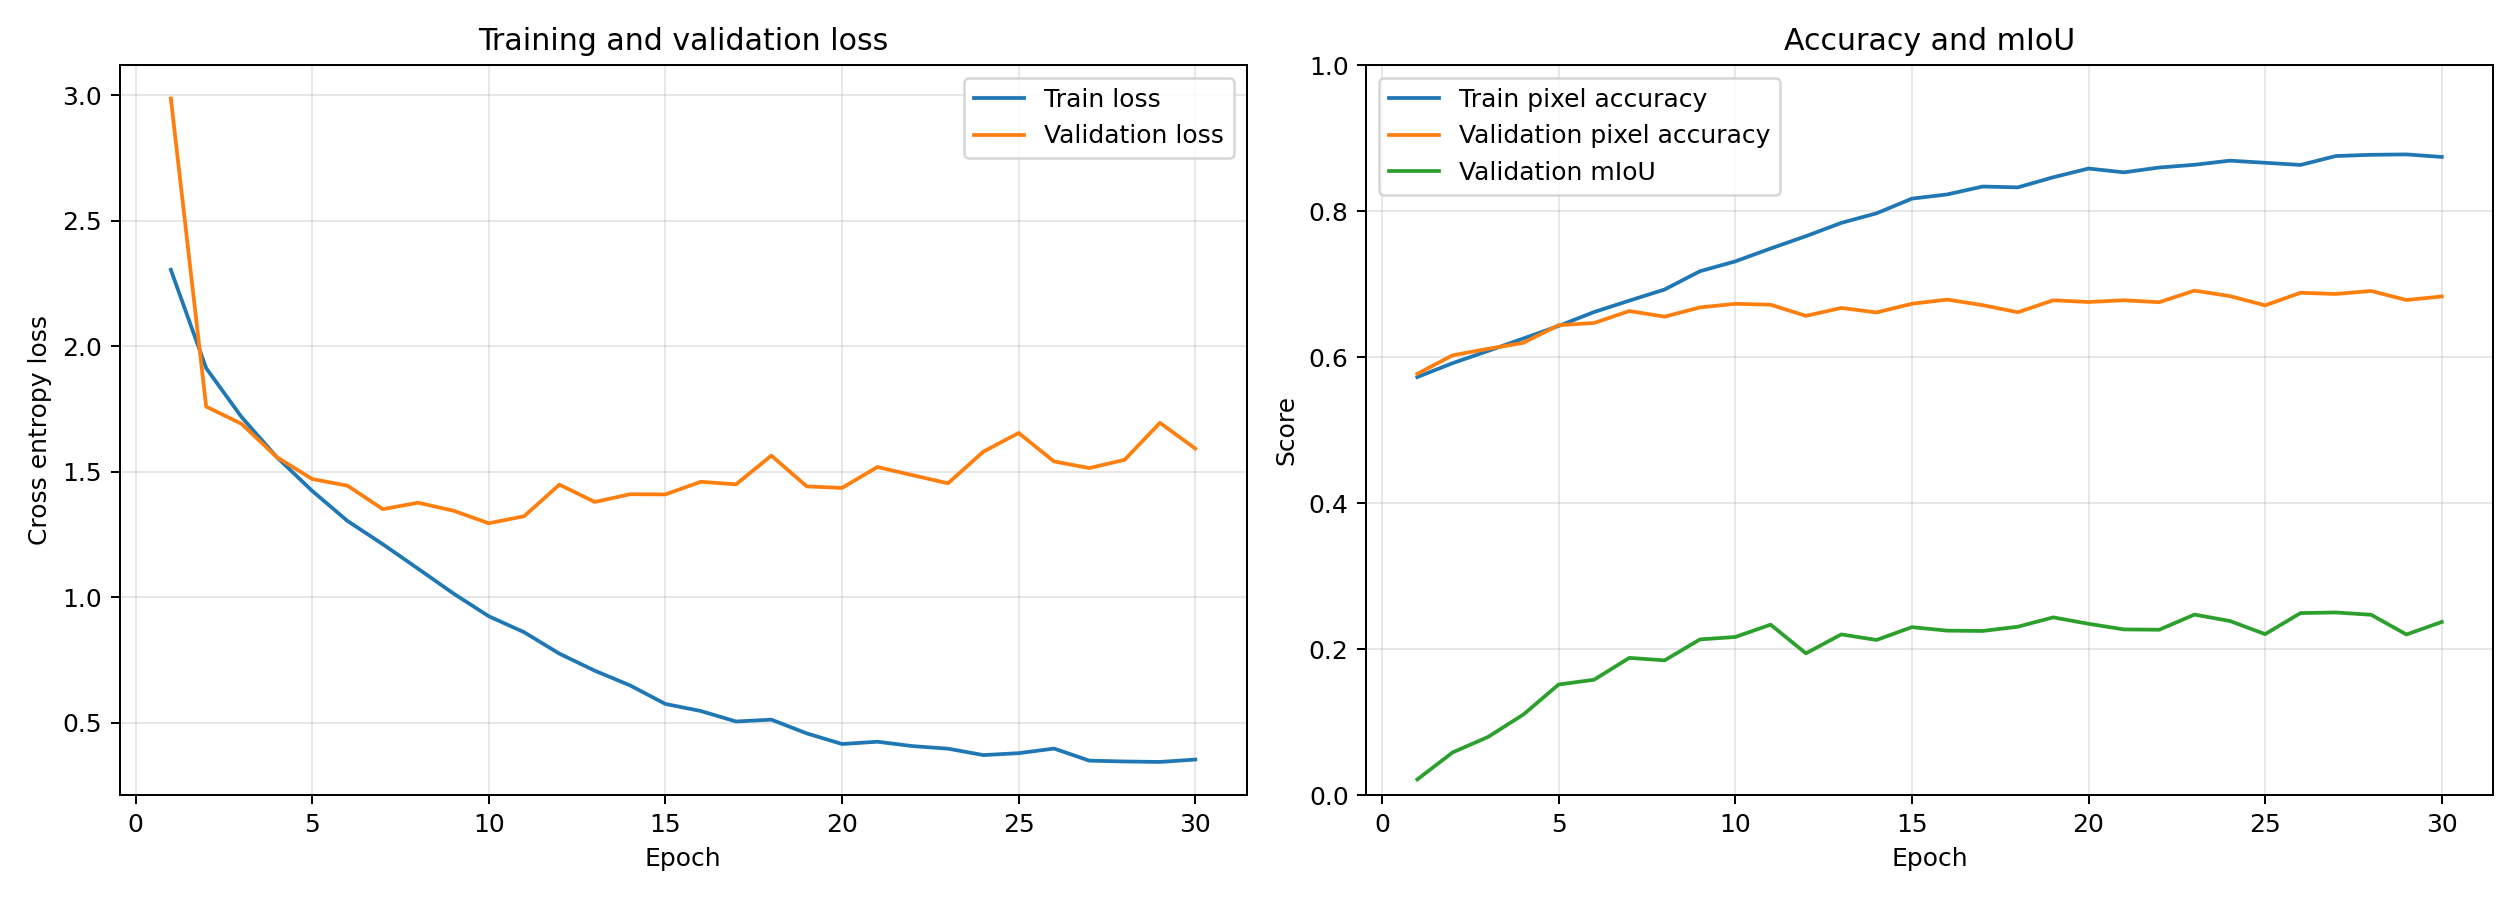

In [6]:
# ====== COMPLETED 30-EPOCH EXPERIMENT ======
# The rendered curve is embedded in the notebook output below.


---
## 7. Results & Discussion

| Metric | Result |
|---|---:|
| Best validation mIoU | **0.2503 (25.03%)** |
| Best epoch by mIoU | **27** |
| Validation pixel accuracy at best epoch | **0.6868 (68.68%)** |
| Validation loss at best epoch | **1.5146** |

Training loss continued to decrease while validation performance later fluctuated. This indicates overfitting, so the best validation-mIoU epoch is reported instead of the final epoch.

---
## 8. Reference

Huang, G., Liu, Z., van der Maaten, L., and Weinberger, K. Q. (2017). *Densely Connected Convolutional Networks*. CVPR.